# **Penerapan PySpark dalam Analisis Popularitas Lagu Spotify Berdasarkan Genre dan Karakteristik Audio**

#### **Spark Initialization**

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window

# 1. Inisialisasi SparkSession (Optimization dengan pengaturan shuffle partitions)
spark = (SparkSession.builder
    .appName("Spotify Data Analysis")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate())

print("SparkSession berhasil diinisialisasi!")
print(f"Spark version : {spark.version}")
print(f"App Name : {spark.conf.get('spark.app.name')}")

SparkSession berhasil diinisialisasi!
Spark version : 4.0.2
App Name : Spotify Data Analysis


#### **Scrapping Data**

In [ ]:
import requests
import pandas as pd
import time

all_rows = []

headers = {
    "User-Agent": "Mozilla/5.0"
}

for offset in range(0, 10000, 100):

    success = False

    while not success:

        try:
            url = f"https://datasets-server.huggingface.co/rows?dataset=GildasLeDrogoff/spotify-huge-track-analysis-dataset&config=default&split=train&offset={offset}&length=100"

            response = requests.get(url, headers=headers)

            # sukses
            if response.status_code == 200:

                data_json = response.json()

                rows = [item['row'] for item in data_json['rows']]
                all_rows.extend(rows)

                print(f"Berhasil mengambil {offset + 100} data")

                success = True

                # delay normal
                time.sleep(2)

            # rate limit
            elif response.status_code == 429:

                print(f"Rate limit pada offset {offset}, menunggu 10 detik...")
                time.sleep(10)

            # server error
            elif response.status_code == 502:

                print(f"Server error 502 pada offset {offset}, retry...")
                time.sleep(5)

            else:
                print(f"Error status {response.status_code} pada offset {offset}")
                success = True

        except Exception as e:
            print(f"Error pada offset {offset}: {e}")
            time.sleep(5)

df_pd = pd.DataFrame(all_rows)

df_pd.to_csv("spotify_dataset_10000.csv", index=False)

print(df_pd.head())
print(df_pd.shape)

Berhasil mengambil 100 data
Berhasil mengambil 200 data
Berhasil mengambil 300 data
Berhasil mengambil 400 data
Berhasil mengambil 500 data
Berhasil mengambil 600 data
Berhasil mengambil 700 data
Berhasil mengambil 800 data
Berhasil mengambil 900 data
Berhasil mengambil 1000 data
Berhasil mengambil 1100 data
Berhasil mengambil 1200 data
Berhasil mengambil 1300 data
Berhasil mengambil 1400 data
Berhasil mengambil 1500 data
Berhasil mengambil 1600 data
Berhasil mengambil 1700 data
Berhasil mengambil 1800 data
Berhasil mengambil 1900 data
Berhasil mengambil 2000 data
Berhasil mengambil 2100 data
Berhasil mengambil 2200 data
Berhasil mengambil 2300 data
Berhasil mengambil 2400 data
Berhasil mengambil 2500 data
Berhasil mengambil 2600 data
Rate limit pada offset 2600, menunggu 10 detik...
Rate limit pada offset 2600, menunggu 10 detik...
Rate limit pada offset 2600, menunggu 10 detik...
Berhasil mengambil 2700 data
Berhasil mengambil 2800 data
Berhasil mengambil 2900 data
Berhasil mengambil

#### **Data Ingestion**

**Data Dictionary**

Dataset ini berisi data fitur audio Spotify dengan variabel sebagai berikut:
- **track_id**: ID unik lagu.
- **artist_name**: Nama artis penyanyi.
- **track_name**: Nama lagu.
- **album_name**: Nama album tempat lagu berada.
- **album_release_date**: Tanggal rilis album.
- **duration_ms**: Durasi lagu dalam milidetik.
- **explicit**: Indikator apakah lagu mengandung konten eksplisit (1 = Ya, 0 = Tidak).
- **track_popularity**: Skor popularitas lagu dari Spotify.
- **artist_popularity**: Skor popularitas sang artis.
- **artist_followers**: Jumlah follower dari artis.
- **tempo**: Tempo lagu dalam ketukan per menit (BPM).
- **key**: Nada dasar dari lagu.
- **mode**: Mode lagu (Mayor atau Minor).
- **danceability**: Ukuran seberapa cocok lagu tersebut untuk digunakan menari (skor 0.0 - 1.0).
- **energy**: Tingkat intensitas, kecepatan, dan noise dari lagu (skor 0.0 - 1.0).
- **loudness**: Kekerasan suara lagu dalam decibel (dB).
- **genre**: Kategori aliran musik (dibuat secara sintetis untuk analisis).
- **release_year**: Tahun rilis album (diekstrak dari album_release_date).
- **duration_minutes**: Durasi lagu dalam hitungan menit.

In [ ]:
# 2. Data Ingestion
csv_path = r"/content/spotify_dataset_10000.csv"

# Membaca data CSV dengan header dan infer schema
df_raw = spark.read.csv(csv_path, header=True, inferSchema=True)

# Mengecek tipe data dan menampilkan 5 baris pertama
df_raw.printSchema()
df_raw.show(5)

# Caching Dataframe untuk optimasi komputasi selanjutnya
df_raw.cache()

root
 |-- track_id: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- album_release_date: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- track_number: string (nullable = true)
 |-- disc_number: integer (nullable = true)
 |-- track_popularity: integer (nullable = true)
 |-- album_popularity: integer (nullable = true)
 |-- track_vs_album_popularity: double (nullable = true)
 |-- artist_popularity: double (nullable = true)
 |-- artist_followers: double (nullable = true)
 |-- album_vs_artist_popularity: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- key: double (nullable = true)
 |-- mode: double (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- loudness: double (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: doubl

DataFrame[track_id: string, artist_name: string, track_name: string, album_name: string, album_release_date: string, duration_ms: string, explicit: string, track_number: string, disc_number: int, track_popularity: int, album_popularity: int, track_vs_album_popularity: double, artist_popularity: double, artist_followers: double, album_vs_artist_popularity: double, tempo: double, key: double, mode: double, danceability: double, energy: double, loudness: double, speechiness: double, acousticness: double, instrumentalness: double, liveness: double, valence: double, energy_danceability_score: double]

#####

#### **Pre-Processing, EDA**

In [ ]:
# 3. Data Cleaning & Pengecekan Missing Values
from pyspark.sql.functions import col, sum as spark_sum

print("Total Missing Values untuk setiap kolom:")
# Pengecekan missing values di seluruh dataframe
df_raw.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df_raw.columns]).show()

#atau menggunakan df_raw.isnull.sum()

# EDA Awal (Summary Statistics dari kolom numerik penting untuk memastikan data aman)
print("Summary Statistics (EDA):")
df_raw.select("duration_ms", "track_popularity", "energy", "danceability").describe().show()

Total Missing Values untuk setiap kolom:
+--------+-----------+----------+----------+------------------+-----------+--------+------------+-----------+----------------+----------------+-------------------------+-----------------+----------------+--------------------------+-----+---+----+------------+------+--------+-----------+------------+----------------+--------+-------+-------------------------+
|track_id|artist_name|track_name|album_name|album_release_date|duration_ms|explicit|track_number|disc_number|track_popularity|album_popularity|track_vs_album_popularity|artist_popularity|artist_followers|album_vs_artist_popularity|tempo|key|mode|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|energy_danceability_score|
+--------+-----------+----------+----------+------------------+-----------+--------+------------+-----------+----------------+----------------+-------------------------+-----------------+----------------+--------------------------+-----+

In [ ]:
from pyspark.sql.types import LongType
from pyspark.sql.functions import when, col, lit, regexp_replace, year, round, array, floor, rand

#Drop Missing Values (dropna)
df_clean = df_raw.dropna(how='any')
df_clean

DataFrame[track_id: string, artist_name: string, track_name: string, album_name: string, album_release_date: string, duration_ms: string, explicit: string, track_number: string, disc_number: int, track_popularity: int, album_popularity: int, track_vs_album_popularity: double, artist_popularity: double, artist_followers: double, album_vs_artist_popularity: double, tempo: double, key: double, mode: double, danceability: double, energy: double, loudness: double, speechiness: double, acousticness: double, instrumentalness: double, liveness: double, valence: double, energy_danceability_score: double]

In [ ]:
#Drop Duplicates berdasarkan track_id
df_clean = df_clean.dropDuplicates(["track_id"])

In [ ]:
#Filter lagu dengan durasi yang valid (> 0 ms), duration_ms adalh tipe data str
df_clean = df_clean.withColumn(
    "duration_ms",
    when(col("duration_ms").rlike("^[0-9]+$"), col("duration_ms").cast(LongType()))
    .otherwise(lit(None))
)

df_clean = df_clean.filter(col("duration_ms").isNotNull() & (col("duration_ms") > 0))

In [ ]:
#withColumn - Konversi duration_ms ke menit

df_clean = df_clean.withColumn("duration_minutes", round(col("duration_ms") / 60000, 2))

In [ ]:
# withColumn - Ekstraksi tahun rilis dari album_release_date
df_clean = df_clean.withColumn("release_year", year(col("album_release_date")))

In [ ]:
# withColumn - Pembuatan data genre sintetis secara acak (karena tidak ada di dataset asli)
genres_array = array([lit(g) for g in ['Pop', 'Rock', 'Hip Hop', 'Jazz', 'Classical', 'EDM', 'R&B']])
df_clean = df_clean.withColumn("genre", genres_array.getItem(floor(rand() * 7).cast("int")))

In [ ]:
#Select kolom yang relevan
df_clean = df_clean.select(
    "track_id", "artist_name", "track_name", "genre", "release_year", "explicit",
    "track_popularity", "artist_popularity", "artist_followers",
    "energy", "danceability", "loudness", "duration_minutes"
)

In [ ]:
# Caching DataFrame yang sudah bersih untuk dianalisis
df_clean.cache()

print("Data setelah Pre-processing & Cleaning:")
df_clean.show(5)

Data setelah Pre-processing & Cleaning:
+--------------------+----------------+-----------------+---------+------------+--------+----------------+-----------------+----------------+------+------------+--------+----------------+
|            track_id|     artist_name|       track_name|    genre|release_year|explicit|track_popularity|artist_popularity|artist_followers|energy|danceability|loudness|duration_minutes|
+--------------------+----------------+-----------------+---------+------------+--------+----------------+-----------------+----------------+------+------------+--------+----------------+
|2xYOdsteUXUjvSHsf...|  Matthieu Gonet|   Maison de rêve|      EDM|        2025|       0|               3|             13.0|           616.0| 0.106|       0.077| -18.073|            0.99|
|2xYOf8ex9wnFRVdw8...|              TM|  Don't Criticize|     Rock|        2021|       0|               1|             13.0|           513.0| 0.715|       0.533|  -8.816|            3.08|
|2xYOllJeUAaUKSUqi..

#####

#### **Analisis Top Tracks per Genre**

In [ ]:
df_clean.createOrReplaceTempView("spotify_tracks")

query = """
WITH RankedTracks AS (
    SELECT
        genre,
        track_name,
        artist_name,
        track_popularity,
        ROW_NUMBER() OVER(PARTITION BY genre ORDER BY track_popularity DESC) as rank
    FROM spotify_tracks
)
SELECT * FROM RankedTracks WHERE rank <= 3
"""
top_tracks_per_genre = spark.sql(query)
print("Top 3 Lagu per Genre berdasarkan Popularitas:")
top_tracks_per_genre.show(10)

# Aggregations (Query 1): Rata-rata popularitas per genre
genre_pop_df = df_clean.groupBy("genre").agg(avg("track_popularity").alias("avg_popularity")).orderBy(desc("avg_popularity"))
genre_pop_pd = genre_pop_df.toPandas()

Top 3 Lagu per Genre berdasarkan Popularitas:
+---------+--------------------+--------------+----------------+----+
|    genre|          track_name|   artist_name|track_popularity|rank|
+---------+--------------------+--------------+----------------+----+
|Classical|    Secuelas De Amor|    Carin Leon|              65|   1|
|Classical|        Clear Waters|Soothing Oasis|              60|   2|
|Classical|             Bizarro|   $uicideboy$|              53|   3|
|      EDM|        Badnam Gabru|Manisha Sharma|              67|   1|
|      EDM|          Ignorantes|     Bad Bunny|              63|   2|
|      EDM|Twinkle Twinkle L...|  Little Teddy|              58|   3|
|  Hip Hop|TILL L4TE (feat. ...|         Aitch|              61|   1|
|  Hip Hop|"Overture - From ...|Justin Hurwitz|              52|   2|
|  Hip Hop|             Adeline|       The Dip|              51|   3|
|     Jazz|"Verappa - From "...|         Arivu|              61|   1|
+---------+--------------------+------------

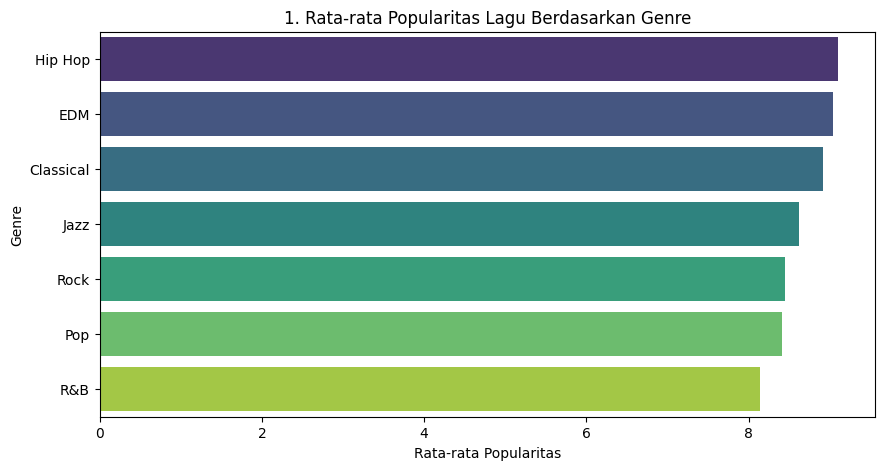

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='avg_popularity', y='genre', data=genre_pop_pd, palette='viridis')
plt.title('1. Rata-rata Popularitas Lagu Berdasarkan Genre')
plt.xlabel('Rata-rata Popularitas')
plt.ylabel('Genre')
plt.show()

In [ ]:
query = """
WITH RankedTracks AS (
    SELECT
        genre,
        track_name,
        artist_name,
        track_popularity,
        ROW_NUMBER() OVER(ORDER BY track_popularity DESC) as rank
    FROM spotify_tracks
)
SELECT * FROM RankedTracks
WHERE rank <= 10
"""

top_tracks_overall = spark.sql(query)

print("Top 10 Lagu Paling Populer Secara Keseluruhan:")
top_tracks_overall.show()

# Convert Spark DataFrame ke Pandas
top_tracks_pd = top_tracks_overall.toPandas()

# Urutkan dari rank terbesar ke kecil untuk visualisasi
top_tracks_pd = top_tracks_pd.sort_values(
    by="track_popularity",
    ascending=True
)

Top 10 Lagu Paling Populer Secara Keseluruhan:
+---------+--------------------+--------------+----------------+----+
|    genre|          track_name|   artist_name|track_popularity|rank|
+---------+--------------------+--------------+----------------+----+
|      Pop|             Awkward|           SZA|              75|   1|
|      EDM|        Badnam Gabru|Manisha Sharma|              67|   2|
|Classical|    Secuelas De Amor|    Carin Leon|              65|   3|
|      R&B|   Always On My Mind| Willie Nelson|              64|   4|
|      EDM|          Ignorantes|     Bad Bunny|              63|   5|
|      R&B|            Sem Foto|        L7NNON|              62|   6|
|     Jazz|"Verappa - From "...|         Arivu|              61|   7|
|  Hip Hop|TILL L4TE (feat. ...|         Aitch|              61|   8|
|Classical|        Clear Waters|Soothing Oasis|              60|   9|
|      EDM|Twinkle Twinkle L...|  Little Teddy|              58|  10|
+---------+--------------------+-----------

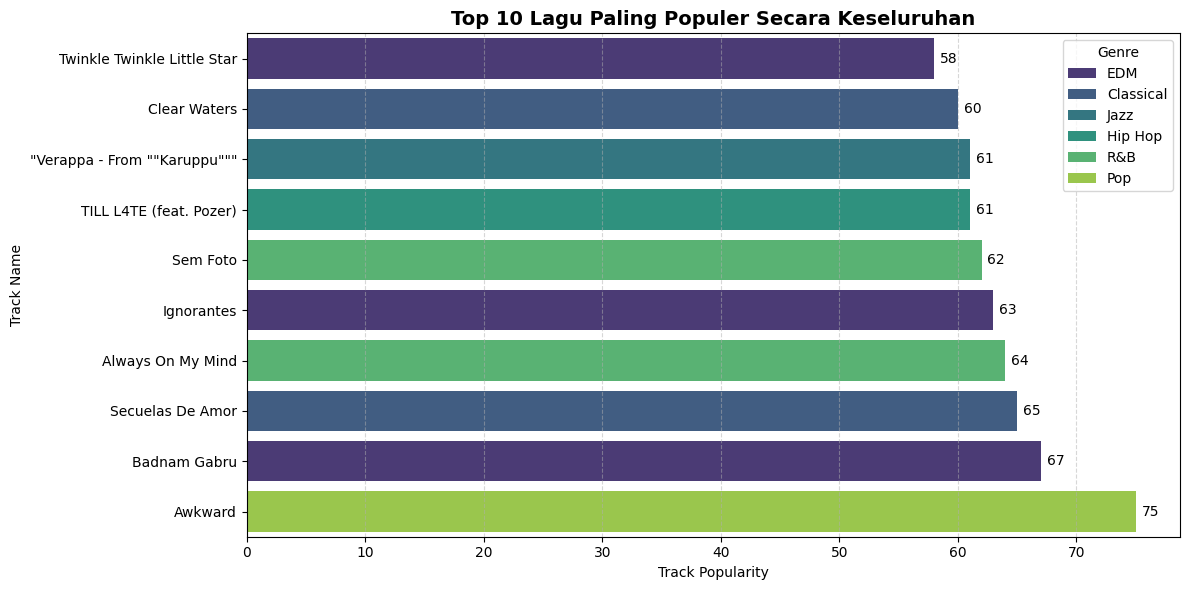

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_tracks_pd,
    x="track_popularity",
    y="track_name",
    hue="genre",
    palette="viridis"
)
plt.title(
    "Top 10 Lagu Paling Populer Secara Keseluruhan",
    fontsize=14,
    weight='bold'
)
plt.xlabel("Track Popularity")
plt.ylabel("Track Name")

for index, value in enumerate(top_tracks_pd["track_popularity"]):
    plt.text(
        value + 0.5,
        index,
        str(value),
        va='center'
    )
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

#####

#### **Tren Popularitas Genre**

In [ ]:
import plotly.express as px

# Aggregations (Query 2): Rata-rata popularitas genre per tahun
trend_df = df_clean.filter(col("release_year") >= 2010) \
    .groupBy("release_year", "genre") \
    .agg(avg("track_popularity").alias("avg_popularity")) \
    .orderBy("release_year")

trend_pd = trend_df.toPandas()

fig = px.line(
    trend_pd,
    x='release_year',
    y='avg_popularity',
    color='genre',
    markers=True,
    title='Tren Popularitas Genre dari Tahun ke Tahun'
)

fig.update_layout(
    xaxis_title='Tahun Rilis',
    yaxis_title='Rata-rata Popularitas',
    hovermode='x unified'
)

fig.show()

In [ ]:
import plotly.express as px

# Aggregations (Query 2): Rata-rata popularitas genre per tahun
trend_df = df_clean.filter(col("release_year").between(2020,2025)) \
    .groupBy("release_year", "track_name") \
    . \
    .orderBy("release_year")

trend_pd = trend_df.toPandas()

fig = px.line(
    trend_pd,
    x='release_year',
    y='avg_popularity',
    color='genre',
    markers=True,
    title='Tren Popularitas Genre dari Tahun ke Tahun'
)

fig.update_layout(
    xaxis_title='Tahun Rilis',
    yaxis_title='Rata-rata Popularitas',
    hovermode='x unified'
)

fig.show()

#### **Explicit Content vs Non-Explicit**

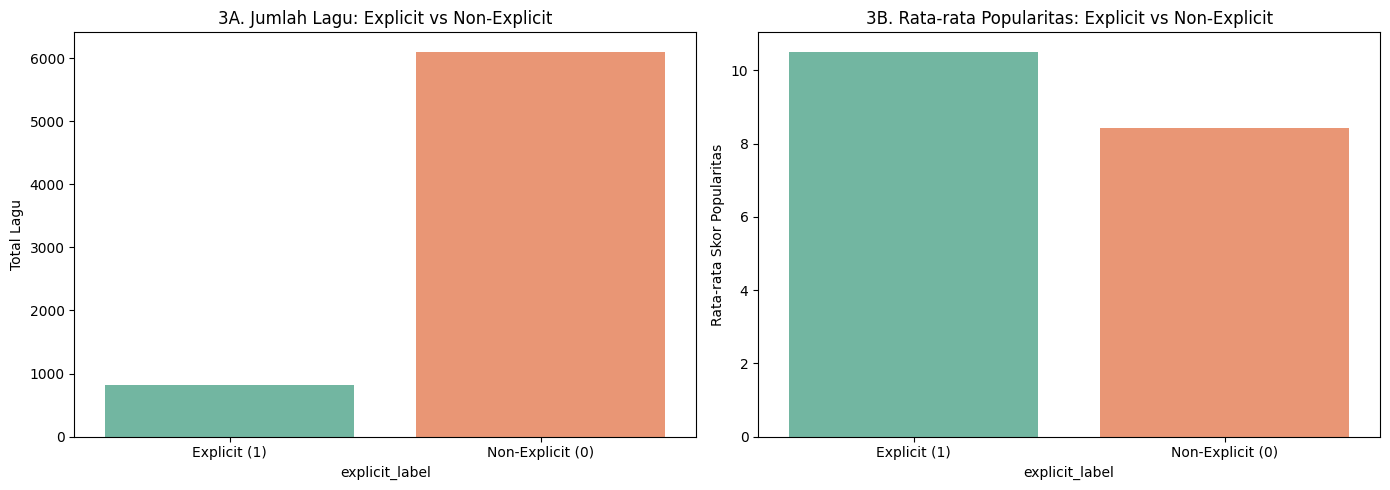

In [ ]:
explicit_df = df_clean.groupBy("explicit").agg(
    count("*").alias("total_tracks"),
    avg("track_popularity").alias("avg_popularity")
).toPandas()

# Convert 'explicit' column to integer type before mapping
explicit_df['explicit'] = explicit_df['explicit'].astype(int)
explicit_df['explicit_label'] = explicit_df['explicit'].map({1: 'Explicit (1)', 0: 'Non-Explicit (0)'})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='explicit_label', y='total_tracks', data=explicit_df, ax=ax[0], palette='Set2')
ax[0].set_title('3A. Jumlah Lagu: Explicit vs Non-Explicit')
ax[0].set_ylabel('Total Lagu')

sns.barplot(x='explicit_label', y='avg_popularity', data=explicit_df, ax=ax[1], palette='Set2')
ax[1].set_title('3B. Rata-rata Popularitas: Explicit vs Non-Explicit')
ax[1].set_ylabel('Rata-rata Skor Popularitas')
plt.tight_layout()
plt.show()

#### **Popularity Score & Distribusi Followers**

In [ ]:
# Join Operations
dim_artist = df_clean.select("artist_name", "artist_popularity", "artist_followers").distinct()

# Membuat Fact Table
fact_tracks = df_clean.select("track_id", "track_name", "artist_name", "track_popularity")

# Inner Join
joined_df = fact_tracks.join(dim_artist, on="artist_name", how="inner")
print("Hasil Join (Fakta Lagu digabungkan dengan Dimensi Artis):")
joined_df.show(5)

#tambahiinn row sebelum join dan sesudah
artist_pd = dim_artist.toPandas()

Hasil Join (Fakta Lagu digabungkan dengan Dimensi Artis):
+----------------+--------------------+-----------------+----------------+-----------------+----------------+
|     artist_name|            track_id|       track_name|track_popularity|artist_popularity|artist_followers|
+----------------+--------------------+-----------------+----------------+-----------------+----------------+
|  Matthieu Gonet|2xYOdsteUXUjvSHsf...|   Maison de rêve|               3|             13.0|           616.0|
|              TM|2xYOf8ex9wnFRVdw8...|  Don't Criticize|               1|             13.0|           513.0|
|      The Clause|2xYOllJeUAaUKSUqi...|    Forever Young|              32|             39.0|         20006.0|
|Tshering Yangdon|2xYP1ebNff6Tcn3wp...|      Jana Norbu.|               5|             16.0|          3579.0|
|         MSWHITE|2xYPCGPi91oErtBTj...|I Breathe The Sun|              10|              4.0|          1253.0|
+----------------+--------------------+-----------------+-----

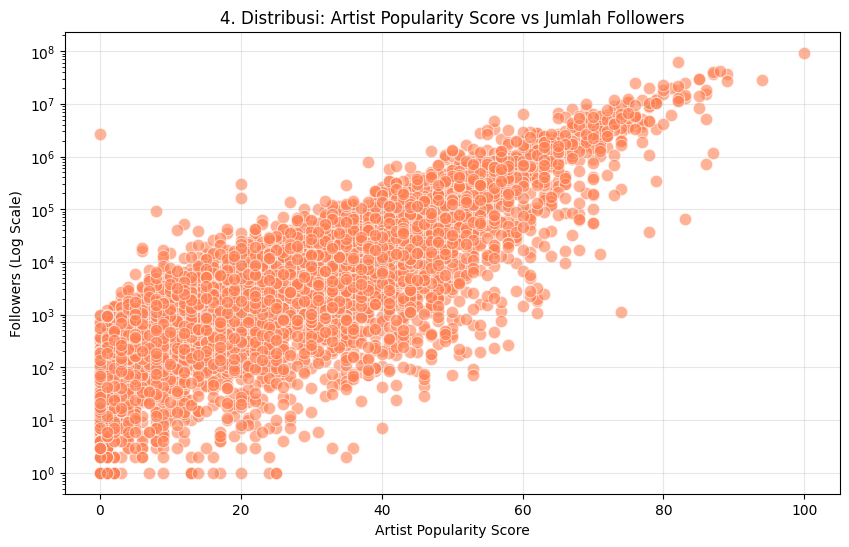

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='artist_popularity', y='artist_followers', data=artist_pd, alpha=0.6, color='coral', s=80)
plt.title('4. Distribusi: Artist Popularity Score vs Jumlah Followers')
plt.xlabel('Artist Popularity Score')
plt.ylabel('Followers (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

#### **Korelasi Antara Energy, Danceability, dan Popularitas**

In [ ]:
corr_df = df_clean.select("energy", "danceability", "track_popularity", "loudness").toPandas()
corr_matrix = corr_df.corr()
corr_matrix

,energy,danceability,track_popularity,loudness
energy,1.000000,0.226852,0.120679,0.778642
danceability,0.226852,1.000000,0.087500,0.299356
track_popularity,0.120679,0.087500,1.000000,0.132355
loudness,0.778642,0.299356,0.132355,1.000000


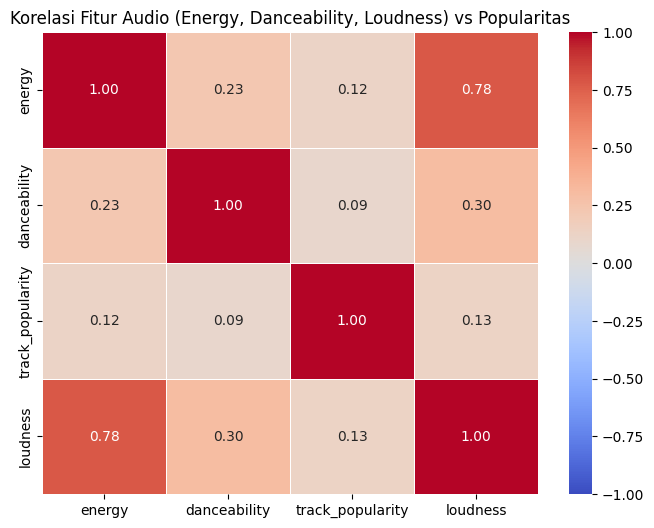

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Korelasi Fitur Audio (Energy, Danceability, Loudness) vs Popularitas')
plt.show()

In [ ]:
import builtins

# Membuat tabel korelasi berdasarkan heatmap

hasil_korelasi = []

for i in corr_matrix.columns:
    for j in corr_matrix.columns:

        # Menghindari duplikasi dan korelasi diri sendiri
        if i < j:

            corr_value = corr_matrix.loc[i, j]

            # Menentukan kekuatan korelasi
            abs_corr = builtins.abs(corr_value)

            if abs_corr >= 0.7:
                strength = "Sangat Kuat"
            elif abs_corr >= 0.5:
                strength = "Kuat"
            elif abs_corr >= 0.3:
                strength = "Sedang"
            elif abs_corr >= 0.1:
                strength = "Lemah"
            else:
                strength = "Sangat Lemah / Tidak Berkorelasi"

            # Menentukan arah korelasi
            if corr_value > 0:
                direction = "Positif"
            elif corr_value < 0:
                direction = "Negatif"
            else:
                direction = "Netral"

            hasil_korelasi.append({
                "Variabel 1": i,
                "Variabel 2": j,
                "Nilai Korelasi": builtins.round(corr_value, 2),
                "Arah": direction,
                "Kekuatan Korelasi": strength
            })

# Ubah jadi DataFrame
tabel_korelasi = pd.DataFrame(hasil_korelasi)

# Tampilkan tabel
tabel_korelasi

,Variabel 1,Variabel 2,Nilai Korelasi,Arah,Kekuatan Korelasi
0,energy,track_popularity,0.12,Positif,Lemah
1,energy,loudness,0.78,Positif,Sangat Kuat
2,danceability,energy,0.23,Positif,Lemah
3,danceability,track_popularity,0.09,Positif,Sangat Lemah / Tidak Berkorelasi
4,danceability,loudness,0.30,Positif,Lemah
5,loudness,track_popularity,0.13,Positif,Lemah


#### **MLlib: K-Means Clustering & Evaluasi Model**

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [ ]:
# Menyiapkan fitur (features column) untuk MLlib
assembler = VectorAssembler(inputCols=["energy", "danceability", "loudness"], outputCol="raw_features")
mllib_df = assembler.transform(df_clean.na.drop(subset=["energy", "danceability", "loudness"]))
mllib_df.show(5)

+--------------------+----------------+-----------------+---------+------------+--------+----------------+-----------------+----------------+------+------------+--------+----------------+--------------------+
|            track_id|     artist_name|       track_name|    genre|release_year|explicit|track_popularity|artist_popularity|artist_followers|energy|danceability|loudness|duration_minutes|        raw_features|
+--------------------+----------------+-----------------+---------+------------+--------+----------------+-----------------+----------------+------+------------+--------+----------------+--------------------+
|2xYOdsteUXUjvSHsf...|  Matthieu Gonet|   Maison de rêve|      EDM|        2025|       0|               3|             13.0|           616.0| 0.106|       0.077| -18.073|            0.99|[0.106,0.077,-18....|
|2xYOf8ex9wnFRVdw8...|              TM|  Don't Criticize|     Rock|        2021|       0|               1|             13.0|           513.0| 0.715|       0.533|  -

In [ ]:
# Standardisasi fitur untuk menghindari bias pada rentang skala yang berbeda
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(mllib_df)
mllib_scaled = scaler_model.transform(mllib_df)

In [ ]:
# Loop untuk menghitung Silhouette Score pada beberapa nilai K
silhouette_results = []
evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")

for k in range(2, 6):
    kmeans = KMeans().setK(k).setSeed(42).setFeaturesCol("features")
    model = kmeans.fit(mllib_scaled)
    predictions = model.transform(mllib_scaled)

    score = evaluator.evaluate(predictions)
    silhouette_results.append({"K": k, "Silhouette Score": builtins.round(float(score), 4)})

# Menampilkan hasil dalam bentuk DataFrame Pandas
silhouette_table = pd.DataFrame(silhouette_results)
print("Tabel Evaluasi K-Means (Silhouette Score):")
display(silhouette_table)

Tabel Evaluasi K-Means (Silhouette Score):


,K,Silhouette Score
0,2,0.5919
1,3,0.4521
2,4,0.4924
3,5,0.4891


Memulai perhitungan metrik klastering (hanya WSSSE untuk Elbow Method)...
  Selesai K=2
  Selesai K=3
  Selesai K=4
  Selesai K=5
  Selesai K=6
  Selesai K=7
  Selesai K=8
  Selesai K=9
  Selesai K=10


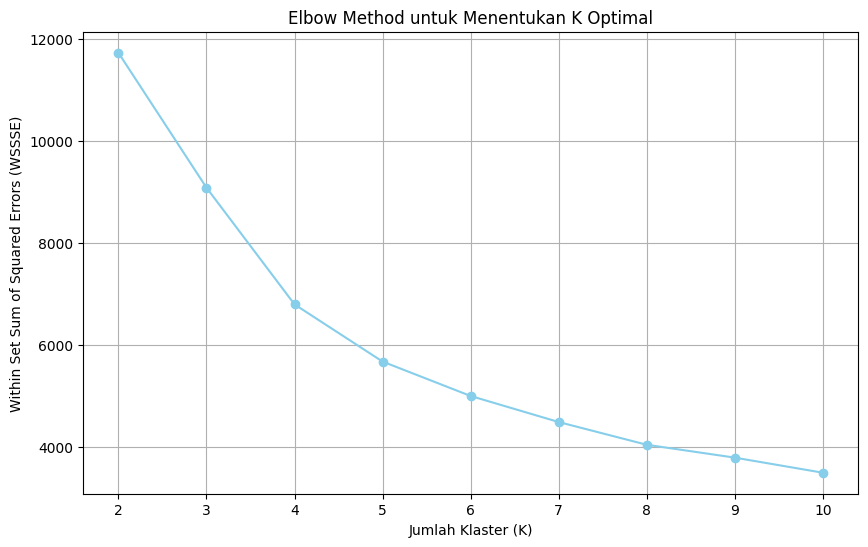


Nilai WSSSE untuk Elbow Method:
  K=2: 11736.18
  K=3: 9086.39
  K=4: 6793.44
  K=5: 5670.02
  K=6: 4994.41
  K=7: 4482.62
  K=8: 4036.08
  K=9: 3783.51
  K=10: 3487.33


In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator # Tetap diimpor karena digunakan untuk Silhouette jika ada
import matplotlib.pyplot as plt
import pandas as pd
import builtins # Digunakan di sel sebelumnya, baik untuk konsistensi

wssse_scores = []
k_values = range(2, 11) # Evaluasi K dari 2 hingga 10

print("Memulai perhitungan metrik klastering (hanya WSSSE untuk Elbow Method)...")

for k in k_values:
    # Melatih model KMeans
    kmeans = KMeans().setK(k).setSeed(42).setFeaturesCol("features")
    model = kmeans.fit(mllib_scaled)
    predictions = model.transform(mllib_scaled)

    # Mendapatkan WSSSE (Within Set Sum of Squared Errors) atau trainingCost
    wssse = model.summary.trainingCost
    wssse_scores.append(wssse)

    print(f"  Selesai K={k}")

# Plotting Elbow Method (WSSSE)
plt.figure(figsize=(10, 6))
plt.plot(k_values, wssse_scores, marker='o', linestyle='-', color='skyblue')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Within Set Sum of Squared Errors (WSSSE)')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

print("\nNilai WSSSE untuk Elbow Method:")
for k, wssse in zip(k_values, wssse_scores):
    print(f"  K={k}: {builtins.round(wssse, 2)}")

In [ ]:
# Plot hasil klastering
cluster_pd = predictions.select("energy", "danceability", "prediction").toPandas()

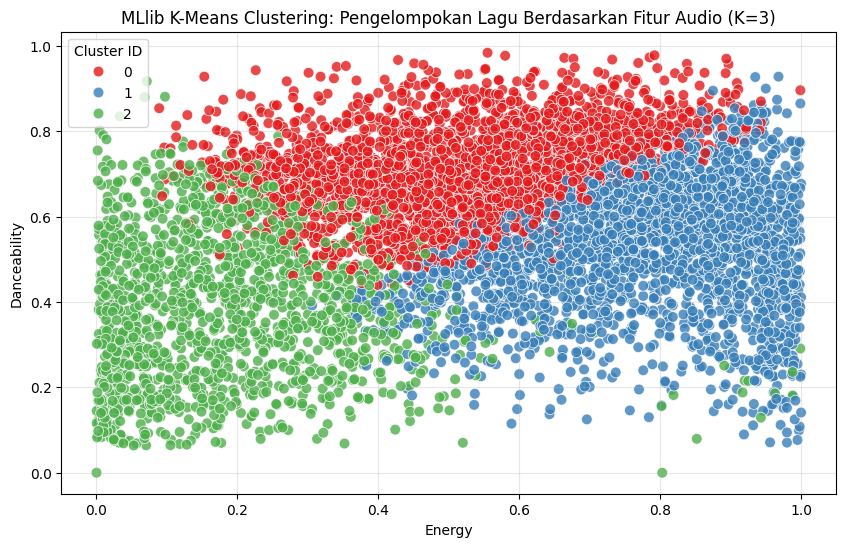

In [ ]:
#K-Means dengan K=3
kmeans_k3 = KMeans().setK(3).setSeed(42).setFeaturesCol("features")
model_k3 = kmeans_k3.fit(mllib_scaled)
predictions_k3 = model_k3.transform(mllib_scaled)

# Convert ke Pandas untuk plotting
cluster_pd_k3 = predictions_k3.select("energy", "danceability", "prediction").toPandas()

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x='energy', y='danceability', hue='prediction', data=cluster_pd_k3, palette='Set1', s=60, alpha=0.8)
plt.title('MLlib K-Means Clustering: Pengelompokan Lagu Berdasarkan Fitur Audio (K=3)')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# INFORMASI SETIAP CLUSTER (Menggunakan hasil K=3)

cluster_info = predictions_k3.groupBy("prediction").avg(
    "energy",
    "danceability",
    "loudness"
).toPandas()

# Rename kolom biar lebih rapi
cluster_info.columns = [
    "Cluster",
    "Rata-rata Energy",
    "Rata-rata Danceability",
    "Rata-rata Loudness"
]

# Membulatkan angka
cluster_info = cluster_info.round(2)

# Menampilkan tabel
cluster_info

,Cluster,Rata-rata Energy,Rata-rata Danceability,Rata-rata Loudness
0,2,0.20,0.40,-19.82
1,1,0.78,0.53,-6.34
2,0,0.50,0.71,-10.48


In [ ]:
# JUMLAH LAGU PER CLUSTER (Menggunakan hasil K=3)
jumlah_cluster = predictions_k3.groupBy("prediction").count().toPandas()

jumlah_cluster.columns = ["Cluster", "Jumlah Lagu"]

display(jumlah_cluster)

,Cluster,Jumlah Lagu
0,2,1557
1,1,2597
2,0,2766


#### **Spark Streaming**

In [ ]:
import tempfile
import shutil

# 1. Membuat direktori sementara
temp_dir = tempfile.mkdtemp(prefix="spark_stream_")

# 2. Kita umpan beberapa data (20 baris pertama) ke dalam folder tersebut untuk di-stream
df_clean.limit(20).write.mode("overwrite").csv(temp_dir, header=True)

# 3. Konfigurasi ReadStream
stream_schema = df_clean.schema
stream_df = spark.readStream \
    .schema(stream_schema) \
    .option("maxFilesPerTrigger", 1) \
    .csv(temp_dir, header=True)

# 4. Memulai WriteStream (Query in-memory sementara)
query = stream_df.writeStream \
    .format("memory") \
    .queryName("live_spotify_stream") \
    .outputMode("append") \
    .start()

print("Membaca data stream yang masuk...")
time.sleep(5)  # Biarkan streaming mengumpulkan data selama 5 detik

Membaca data stream yang masuk...


In [ ]:
# Melihat output yang ditangkap dari aliran streaming
print("Data hasil tangkapan Spark Streaming (Live Table View):")
spark.sql("SELECT track_name, artist_name, genre FROM live_spotify_stream LIMIT 5").show(truncate=False)

Data hasil tangkapan Spark Streaming (Live Table View):
+-----------------+----------------+---------+
|track_name       |artist_name     |genre    |
+-----------------+----------------+---------+
|Maison de rêve   |Matthieu Gonet  |Pop      |
|Don't Criticize  |TM              |Jazz     |
|Forever Young    |The Clause      |Classical|
|Jana Norbu.      |Tshering Yangdon|EDM      |
|I Breathe The Sun|MSWHITE         |Classical|
+-----------------+----------------+---------+



In [ ]:
# Mematikan query dan pembersihan
query.stop()
print("Streaming Query berhasil dihentikan secara aman.")
shutil.rmtree(temp_dir, ignore_errors=True)

# Mematikan Spark Session di bagian paling akhir notebook
spark.stop()

Streaming Query berhasil dihentikan secara aman.
